
---


# **Analyse Prédictive du Marché d'occasion Automobile au Maroc :**

### **De l'Extraction de Données (Scraping) à l'Estimation des Prix par Machine Learning**

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Partie 1 : Analyse Exploratoire des Données (EDA)**

# **1-Importation et merge de données(Empiler plusieurs fichiers)**

In [ ]:
# import glob
# import os
# import pandas as pd

# # 1. On Spécifier le dossier contenant les fichiers CSV scrapés
# dossier_csv = '/content/drive/MyDrive/scraped_Moteur_data'

# # 2. On Récupérer tous les chemins des fichiers se terminant par .csv
# fichiers_csv = glob.glob(os.path.join(dossier_csv, "*.csv"))

# print(f" {len(fichiers_csv)} fichiers CSV trouvés.")

# # 3. Charger chaque fichier dans une liste de DataFrames Pandas
# liste_df = []
# for fichier in fichiers_csv:
#     try:
#         # Configuration adaptée à ton format d'exportation
#         df = pd.read_csv(fichier, sep=';', encoding='utf-8-sig')
#         liste_df.append(df)
#     except Exception as e:
#         print(f" Erreur lors de la lecture de {fichier}: {e}")

# # 4. On Combine tous les DataFrames en un seul bloc brut
# if liste_df:
#     dataset_brut = pd.concat(liste_df, ignore_index=True)

#     # Définissez le répertoire cible dans Google Drive
#     dossier_save_csv = '/content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026'

#     # S'assurez que le répertoire existe
#     os.makedirs(dossier_save_csv, exist_ok=True)

#     # 5. On Sauvegarde le fichier brut pour l'étape d'EDA
#     nom_fichier_sortie = "dataset_moteur_brut.csv"
#     chemin_complet_sortie = os.path.join(dossier_save_csv, nom_fichier_sortie)
#     dataset_brut.to_csv(chemin_complet_sortie, index=False, sep=';', encoding='utf-8-sig')

#     print(f" Fusion terminée ! dataset brut contient {dataset_brut.shape[0]} lignes et {dataset_brut.shape[1]} colonnes.")
#     print(f" Sauvegardé sous : {chemin_complet_sortie} (Prêt pour le notebook d'EDA)")
# else:
#     print(" Aucun fichier n'a pu être combiné.")

# **2-Exploration de données**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026/dataset_moteur_brut.csv", sep=";")
df.head()

,Lien_de_l'annonce,Prix,Date_de_l'annonce,Ville,Marque,Modèle,Année_Modèle,Kilométrage,Type_de_carburant,Boite_de_vitesses,...,Caméra_de_recul,Vitres_électriques,ABS,ESP,Régulateur_de_vitesse,Limiteur_de_vitesse,Bluetooth,Ordinateur_de_bord,Fermeture_centralisée,Couleur
0,https://www.moteur.ma/fr/voiture/achat-voiture...,110000,"Nov 09, 2025",NaN,Skoda,Rapid,2013.0,"265,000 km",Diesel,Manuelle,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Gris
1,https://www.moteur.ma/fr/voiture/achat-voiture...,Appeler pour le prix,"Nov 08, 2025",Oujda,Mercedes-Benz,Classe C,2026.0,0 km,Diesel,Automatique,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,NaN
2,https://www.moteur.ma/fr/voiture/achat-voiture...,58000,"Nov 09, 2025",NaN,Citroën,Xsara,2001.0,"274,000 km",Diesel,Manuelle,...,Non,Non,Oui,Oui,Non,Non,Oui,Oui,Oui,Gris
3,https://www.moteur.ma/fr/voiture/achat-voiture...,78000,"Nov 08, 2025",Safi,Fiat,Grande Punto,2017.0,"230,000 km",Diesel,Manuelle,...,Non,Oui,Oui,Oui,Non,Oui,Oui,Non,Non,Gris fonce
4,https://www.moteur.ma/fr/voiture/achat-voiture...,57000,"Nov 08, 2025",Casablanca,Nissan,Terrano,2003.0,"340,000 km",Diesel,Manuelle,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Noir


In [ ]:
# Dimension du dataset
df.shape

(34640, 33)

In [ ]:
# les colonnes du dataset
df.columns

Index(['Lien_de_l'annonce', 'Prix', 'Date_de_l'annonce', 'Ville', 'Marque',
       'Modèle', 'Année_Modèle', 'Kilométrage', 'Type_de_carburant',
       'Boite_de_vitesses', 'Puissance_fiscale', 'Nombre_de_portes', 'Origine',
       'Première_main', 'Historique_d_accidents', 'Spécifications_rapides',
       'Jantes_aluminium', 'Airbags', 'Climatisation',
       'Système_de_navigation_GPS', 'Toit_ouvrant', 'Intérieur_cuir',
       'Radar_de_recul', 'Caméra_de_recul', 'Vitres_électriques', 'ABS', 'ESP',
       'Régulateur_de_vitesse', 'Limiteur_de_vitesse', 'Bluetooth',
       'Ordinateur_de_bord', 'Fermeture_centralisée', 'Couleur'],
      dtype='object')

In [ ]:
# informations sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34640 entries, 0 to 34639
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Lien_de_l'annonce          34640 non-null  object 
 1   Prix                       34572 non-null  object 
 2   Date_de_l'annonce          34572 non-null  object 
 3   Ville                      29565 non-null  object 
 4   Marque                     34572 non-null  object 
 5   Modèle                     34572 non-null  object 
 6   Année_Modèle               34556 non-null  float64
 7   Kilométrage                34572 non-null  object 
 8   Type_de_carburant          34557 non-null  object 
 9   Boite_de_vitesses          34501 non-null  object 
 10  Puissance_fiscale          31387 non-null  float64
 11  Nombre_de_portes           28344 non-null  float64
 12  Origine                    997 non-null    object 
 13  Première_main              34572 non-null  obj

Interprétation:
Nous remarquant des colonnes ('Prix', 'Date_de_l'annonce', 'Ville', 'Marque','Modèle', 'Année_Modèle', 'Kilométrage', 'Type_de_carburant','Boite_de_vitesses', 'Puissance_fiscale', 'Nombre_de_portes', 'Origine',) qui contients des valeur vides, et le type de données varie entre type object et type float64.

In [ ]:
# statistiques descriptives
df.describe()

,Année_Modèle,Puissance_fiscale,Nombre_de_portes
count,34556.000000,31387.000000,28344.000000
mean,2008.206534,7.971517,4.782141
std,110.572513,3.414095,0.531003
min,0.000000,0.000000,2.000000
25%,2010.000000,6.000000,5.000000
50%,2016.000000,8.000000,5.000000
75%,2019.000000,8.000000,5.000000
max,2026.000000,95.000000,6.000000


Interprétation:
Nous remarquant qu'il ya des colonne dans la statistique n'est pas appliqué car il sont considirer comme type objet. il faut qu'on change le type dans la fase de transformation.

In [ ]:
# Vérification desvaleurs manquantes
df.isnull().sum()

,0
Lien_de_l'annonce,0
Prix,68
Date_de_l'annonce,68
Ville,5075
Marque,68
Modèle,68
Année_Modèle,84
Kilométrage,68
Type_de_carburant,83
Boite_de_vitesses,139


Interprétation:
Nous remarquant des valeurs manquantes dans les colonnes :
- Prix                            68
- Date_de_l'annonce               68
- Ville                         5075
- Marque                          68
- Modèle                          68
- Année_Modèle                    84
- Kilométrage                     68
- Type_de_carburant               83
- Boite_de_vitesses              139
- Puissance_fiscale             3253
- Nombre_de_portes              6296
- Origine                      33643
- Première_main                   68
- Historique_d_accidents          68
- Spécifications_rapides        2971
- Couleur	                      5719

In [ ]:
# Vérification des doublons
# # 1. Sélectionner toutes les colonnes SAUF 'Lien_de_l'annonce'
colonnes_a_verifier = df.columns.drop("Lien_de_l'annonce")

# 2. Compter les doublons basés uniquement sur ces colonnes
nb_doublons = df.duplicated(subset=colonnes_a_verifier).sum()

print(f"Interprétation: Notres dataset contient {nb_doublons} lignes dupliquées (hors lien de l'annonce) ")

Interprétation: Notres dataset contient 555 lignes dupliquées (hors lien de l'annonce) 


In [ ]:

# 1. Chargement et copie locale pour l'EDA
df_eda = pd.read_csv("/content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026/dataset_moteur_brut.csv", sep=";")

# 2. Conversion sécurisée en numérique sans suppression de lignes
# On force en texte avant le regex pour éviter les bugs avec d'éventuels flottants
df_eda['Prix_Num'] = df_eda['Prix'].astype(str).str.replace(r'[^\d]', '', regex=True)
df_eda['Prix_Num'] = pd.to_numeric(df_eda['Prix_Num'], errors='coerce')

df_eda['Kilometrage_Num'] = df_eda['Kilométrage'].astype(str).str.replace(r'[^\d]', '', regex=True)
df_eda['Kilometrage_Num'] = pd.to_numeric(df_eda['Kilometrage_Num'], errors='coerce')

In [ ]:
df_eda.head()

,Lien_de_l'annonce,Prix,Date_de_l'annonce,Ville,Marque,Modèle,Année_Modèle,Kilométrage,Type_de_carburant,Boite_de_vitesses,...,ABS,ESP,Régulateur_de_vitesse,Limiteur_de_vitesse,Bluetooth,Ordinateur_de_bord,Fermeture_centralisée,Couleur,Prix_Num,Kilometrage_Num
0,https://www.moteur.ma/fr/voiture/achat-voiture...,110000,"Nov 09, 2025",NaN,Skoda,Rapid,2013.0,"265,000 km",Diesel,Manuelle,...,Non,Non,Non,Non,Non,Non,Non,Gris,110000.0,265000.0
1,https://www.moteur.ma/fr/voiture/achat-voiture...,Appeler pour le prix,"Nov 08, 2025",Oujda,Mercedes-Benz,Classe C,2026.0,0 km,Diesel,Automatique,...,Non,Non,Non,Non,Non,Non,Non,NaN,NaN,0.0
2,https://www.moteur.ma/fr/voiture/achat-voiture...,58000,"Nov 09, 2025",NaN,Citroën,Xsara,2001.0,"274,000 km",Diesel,Manuelle,...,Oui,Oui,Non,Non,Oui,Oui,Oui,Gris,58000.0,274000.0
3,https://www.moteur.ma/fr/voiture/achat-voiture...,78000,"Nov 08, 2025",Safi,Fiat,Grande Punto,2017.0,"230,000 km",Diesel,Manuelle,...,Oui,Oui,Non,Oui,Oui,Non,Non,Gris fonce,78000.0,230000.0
4,https://www.moteur.ma/fr/voiture/achat-voiture...,57000,"Nov 08, 2025",Casablanca,Nissan,Terrano,2003.0,"340,000 km",Diesel,Manuelle,...,Non,Non,Non,Non,Non,Non,Non,Noir,57000.0,340000.0


In [ ]:
# statistiques descriptives
df_eda.describe()

,Année_Modèle,Puissance_fiscale,Nombre_de_portes,Prix_Num,Kilometrage_Num
count,34556.000000,31387.000000,28344.000000,3.200600e+04,3.457200e+04
mean,2008.206534,7.971517,4.782141,2.367468e+05,4.460795e+05
std,110.572513,3.414095,0.531003,7.043309e+06,2.339702e+07
min,0.000000,0.000000,2.000000,1.000000e+00,0.000000e+00
25%,2010.000000,6.000000,5.000000,8.400000e+04,5.940075e+04
50%,2016.000000,8.000000,5.000000,1.350000e+05,1.200000e+05
75%,2019.000000,8.000000,5.000000,2.150000e+05,1.850000e+05
max,2026.000000,95.000000,6.000000,1.234568e+09,2.147484e+09


Interprétation:
Nous remarquons des valeurs extrêmes dans le prix et kilométrage, ce qui montre que notre dataset nécessite un nettoyage des valeurs aberrantes.

In [ ]:
# Configurer le style visuel des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

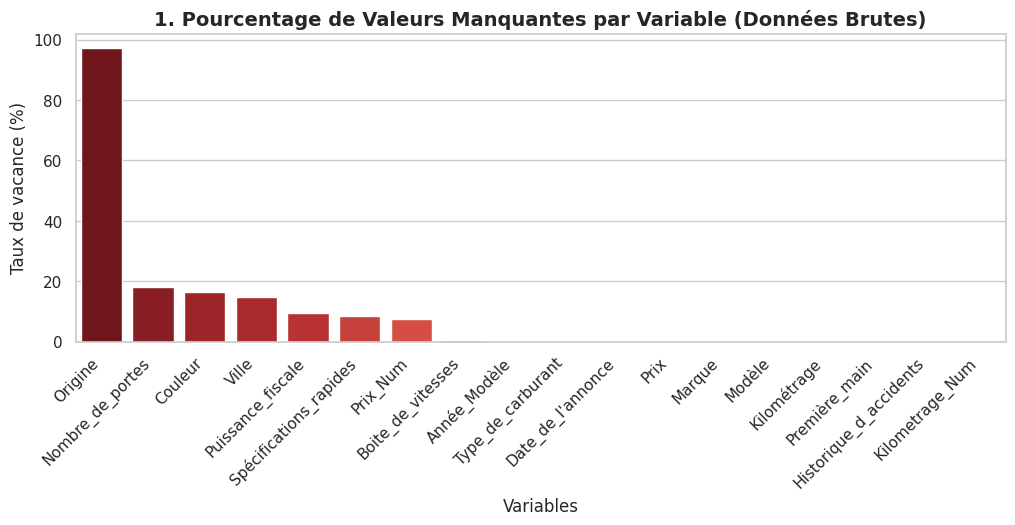

In [ ]:
# GRAPHIQUE 1 : Taux de Valeurs Manquantes (Raw Dataset)

plt.figure(figsize=(12, 4))
manquants_pct = (df_eda.isnull().sum() / len(df_eda)) * 100
manquants_pct = manquants_pct[manquants_pct > 0].sort_values(ascending=False)

# Correction ici : ajout de hue et legend=False pour éliminer le FutureWarning
sns.barplot(x=manquants_pct.index, y=manquants_pct.values, hue=manquants_pct.index, palette="Reds_r", legend=False)
plt.xticks(rotation=45, ha='right')
plt.title("1. Pourcentage de Valeurs Manquantes par Variable (Données Brutes)", fontsize=14, fontweight='bold')
plt.ylabel("Taux de vacance (%)")
plt.xlabel("Variables")
plt.show()

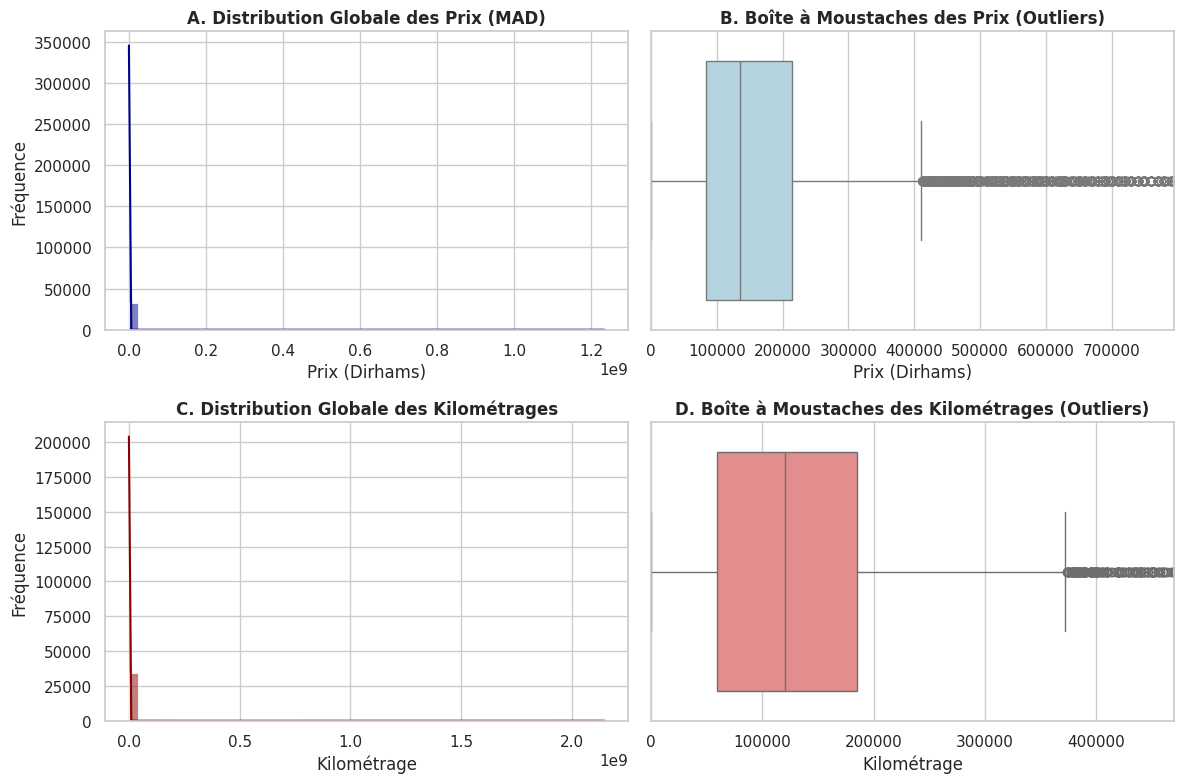

In [ ]:
# 2. Création du premier panneau : Analyse des Prix et Kilométrages
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Calculate 99th percentile for x-axis limits
prix_upper_limit = df_eda['Prix_Num'].quantile(0.99)
kilometrage_upper_limit = df_eda['Kilometrage_Num'].quantile(0.99)

# Graphique A : Histogramme des Prix
sns.histplot(df_eda['Prix_Num'].dropna(), bins=50, kde=True, color="darkblue", ax=axes[0, 0])
axes[0, 0].set_title("A. Distribution Globale des Prix (MAD)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Prix (Dirhams)")
axes[0, 0].set_ylabel("Fréquence")

# Graphique B : Boxplot des Prix (Détection visuelle des anomalies)
sns.boxplot(x=df_eda['Prix_Num'].dropna(), color="lightblue", ax=axes[0, 1])
axes[0, 1].set_title("B. Boîte à Moustaches des Prix (Outliers)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Prix (Dirhams)")
axes[0, 1].set_xlim(0, prix_upper_limit) # Set x-axis limit to 99th percentile

# Graphique C : Histogramme des Kilométrages
sns.histplot(df_eda['Kilometrage_Num'].dropna(), bins=50, kde=True, color="darkred", ax=axes[1, 0])
axes[1, 0].set_title("C. Distribution Globale des Kilométrages", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Kilométrage")
axes[1, 0].set_ylabel("Fréquence")

# Graphique D : Boxplot des Kilométrages (Détection visuelle des anomalies)
sns.boxplot(x=df_eda['Kilometrage_Num'].dropna(), color="lightcoral", ax=axes[1, 1])
axes[1, 1].set_title("D. Boîte à Moustaches des Kilométrages (Outliers)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Kilométrage")
axes[1, 1].set_xlim(0, kilometrage_upper_limit) # Set x-axis limit to 99th percentile

plt.tight_layout() # Ajuste automatiquement les paramètres du subplot pour que les subplots s'adaptent à la figure.
plt.show()

Interprétation des distributions de Prix et Kilométrage:

*   **Distributions de Prix et Kilométrage (Histogrammes A et C):** Les histogrammes montrent des distributions fortement asymétriques à droite (skewed right). La majorité des véhicules ont des prix et des kilométrages plus bas, avec une longue traîne vers des valeurs très élevées. Cela indique la présence de valeurs aberrantes ou extrêmes qui tirent la moyenne vers le haut et augmentent la variance.

*   **Boxplots de Prix et Kilométrage (Boxplots B et D):** Les boxplots, même après avoir limité l'axe des x au 99e percentile, révèlent clairement un grand nombre de points au-delà des "moustaches", confirmant la présence de nombreux outliers significatifs. Ces outliers peuvent grandement influencer les modèles prédictifs, rendant leur interprétation difficile et réduisant leur performance.

**Stratégie qu'on propose pour les outliers:**

Pour gérer ces distributions fortement asymétriques et la présence d'outliers, une transformation logarithmique est une approche courante et efficace. Elle permet de compresser la plage des grandes valeurs et de rendre la distribution plus symétrique, ce qui est souvent bénéfique pour les algorithmes de Machine Learning.

Nous allons appliquer une transformation log(1+x) pour 'Prix_Num' et 'Kilometrage_Num' afin de gérer les valeurs nulles ou zéro, et ensuite visualiser les nouvelles distributions.

In [ ]:
# Application de la transformation logarithmique (log1p pour gérer les zéros)
df_eda['Prix_Num_log'] = np.log1p(df_eda['Prix_Num'])
df_eda['Kilometrage_Num_log'] = np.log1p(df_eda['Kilometrage_Num'])

### Visualisation des distributions après transformation logarithmique

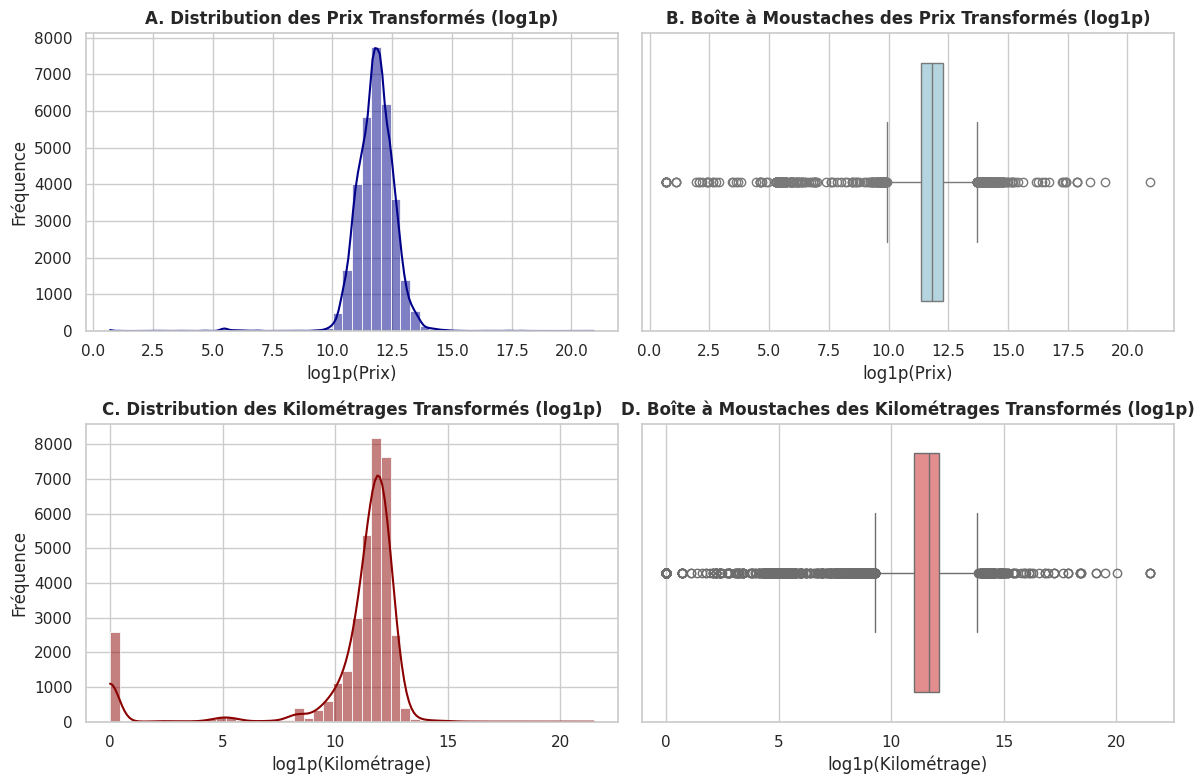

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Graphique A : Histogramme des Prix (log) transformés
sns.histplot(df_eda['Prix_Num_log'].dropna(), bins=50, kde=True, color="darkblue", ax=axes[0, 0])
axes[0, 0].set_title("A. Distribution des Prix Transformés (log1p)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("log1p(Prix)")
axes[0, 0].set_ylabel("Fréquence")

# Graphique B : Boxplot des Prix (log) transformés
sns.boxplot(x=df_eda['Prix_Num_log'].dropna(), color="lightblue", ax=axes[0, 1])
axes[0, 1].set_title("B. Boîte à Moustaches des Prix Transformés (log1p)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("log1p(Prix)")

# Graphique C : Histogramme des Kilométrages (log) transformés
sns.histplot(df_eda['Kilometrage_Num_log'].dropna(), bins=50, kde=True, color="darkred", ax=axes[1, 0])
axes[1, 0].set_title("C. Distribution des Kilométrages Transformés (log1p)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("log1p(Kilométrage)")
axes[1, 0].set_ylabel("Fréquence")

# Graphique D : Boxplot des Kilométrages (log) transformés
sns.boxplot(x=df_eda['Kilometrage_Num_log'].dropna(), color="lightcoral", ax=axes[1, 1])
axes[1, 1].set_title("D. Boîte à Moustaches des Kilométrages Transformés (log1p)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("log1p(Kilométrage)")

plt.tight_layout()
plt.show()

### Interprétation des Distributions après Transformation Logarithmique

Après avoir appliqué la transformation `log1p` sur `Prix_Num` et `Kilometrage_Num`, nous pouvons observer des changements significatifs dans les distributions de ces variables:

*   **Distributions de Prix et Kilométrage (Histogrammes A et C après log)** : Les histogrammes des variables transformées (`Prix_Num_log` et `Kilometrage_Num_log`) montrent des distributions beaucoup plus symétriques, s'approchant d'une forme normale. La forte asymétrie à droite observée précédemment a été considérablement réduite. Cela indique que la transformation logarithmique a réussi à compresser les grandes valeurs et à répartir plus uniformément les données.

*   **Boxplots de Prix et Kilométrage (Boxplots B et D après log)** : Les boxplots des variables transformées confirment également cette amélioration. Bien qu'il puisse encore y avoir quelques points considérés comme des outliers, leur étendue est beaucoup moins prononcée et ils sont mieux intégrés dans l'ensemble de la distribution. Les boîtes sont plus centrées et les moustaches sont plus équilibrées, ce qui signifie que la variabilité des données est mieux représentée et que l'impact des valeurs extrêmes a été atténué.

**Conclusion de la Transformation :**

La transformation `log1p` a été très efficace pour rendre les distributions de `Prix_Num` et `Kilometrage_Num` plus proches de distributions normales. Cette normalisation est cruciale pour de nombreux algorithmes de Machine Learning qui supposent une distribution normale des données ou qui sont sensibles aux outliers et à l'asymétrie. Travailler avec ces variables transformées devrait améliorer la performance et la robustesse de nos futurs modèles.

### Analyse Univarié des Variables Catégorielles

Colonnes catégorielles pour analyse: ['Ville', 'Marque', 'Type_de_carburant', 'Boite_de_vitesses', 'Puissance_fiscale', 'Couleur']


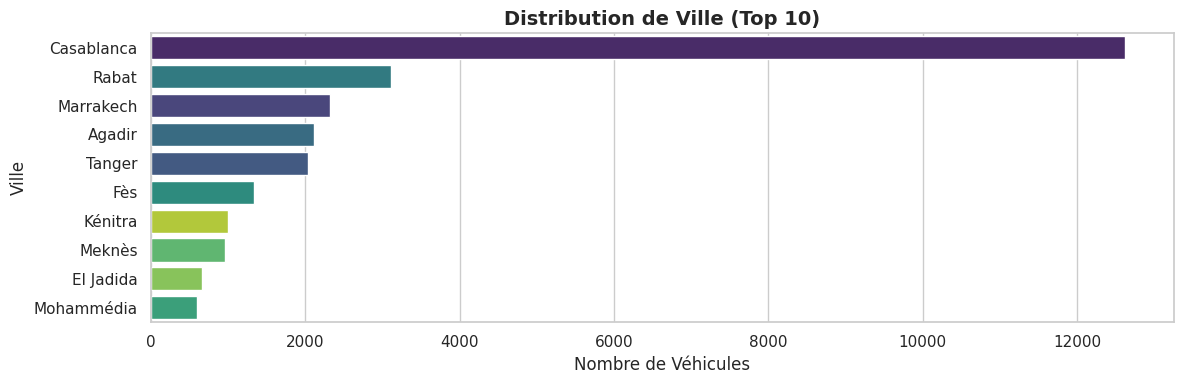

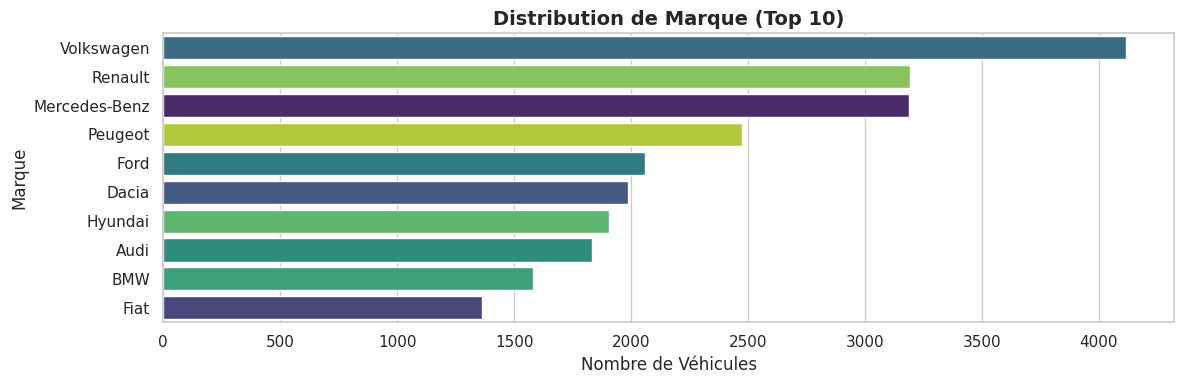

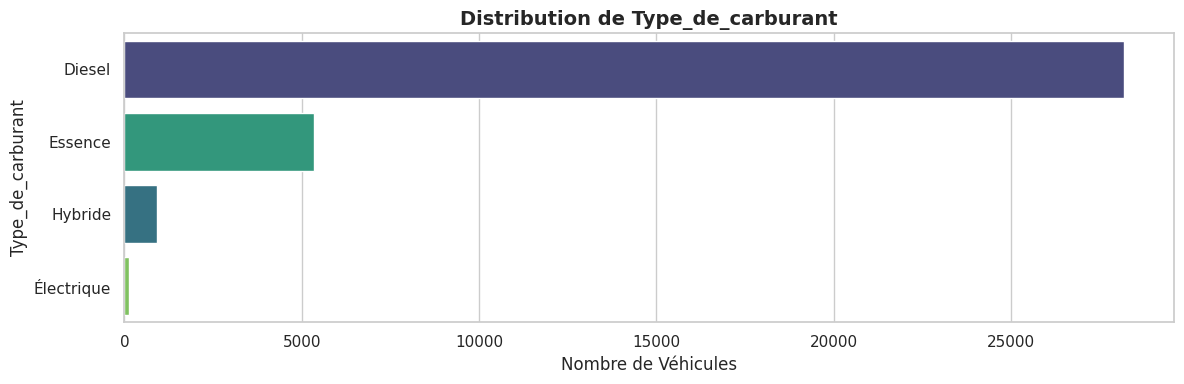

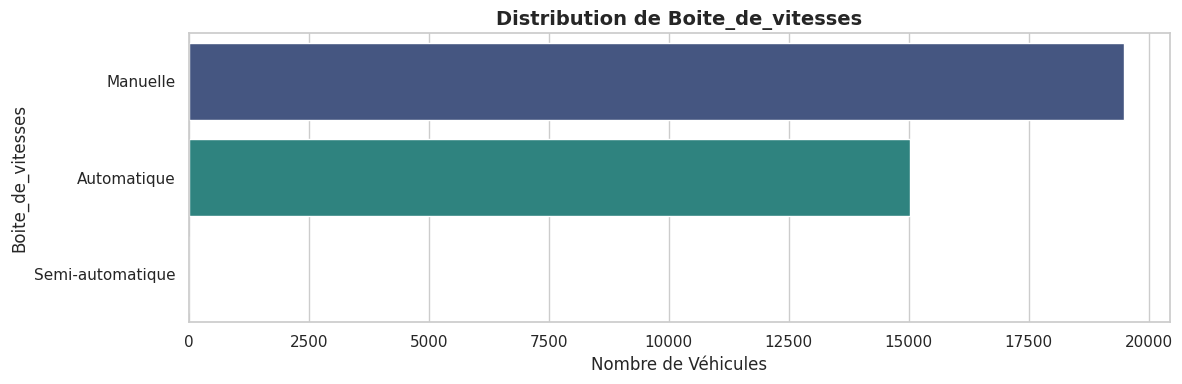

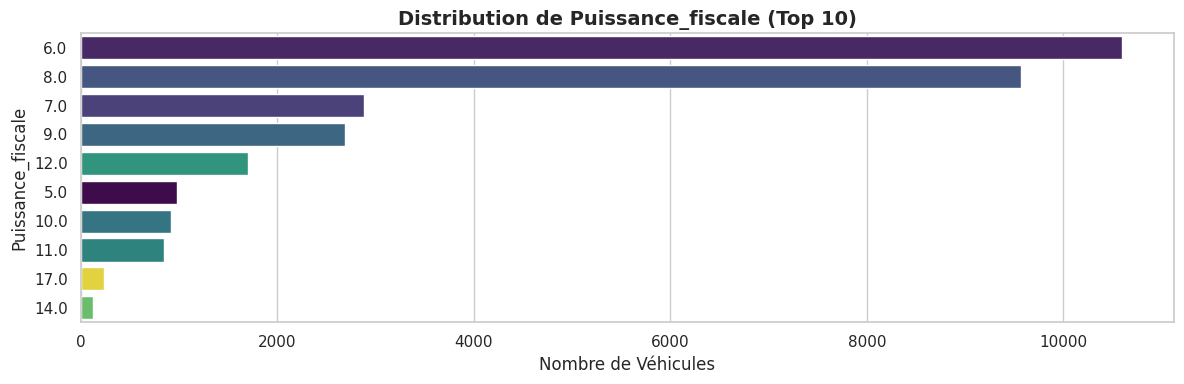

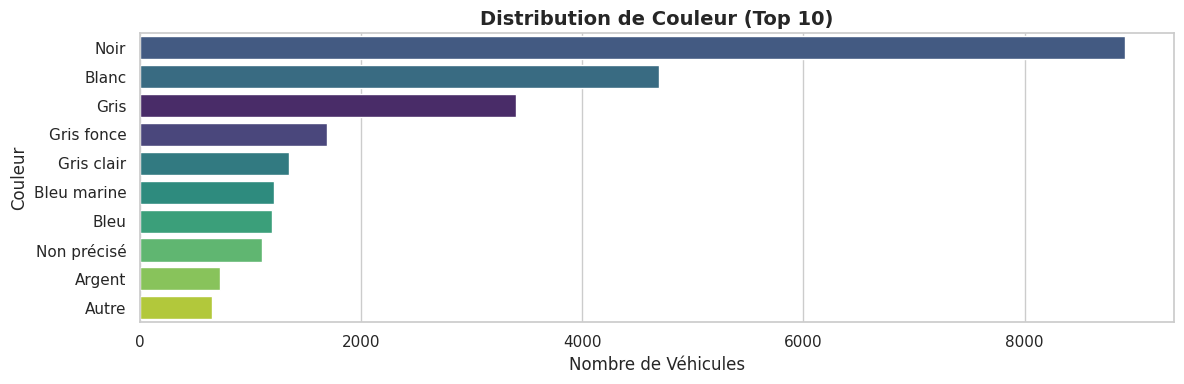

In [ ]:
# Identifier les colonnes catégorielles
# categorical_cols = df_eda.select_dtypes(include='object').columns.tolist()
categorical_cols = ['Ville', 'Marque','Type_de_carburant',
       'Boite_de_vitesses', 'Puissance_fiscale', 'Couleur']

# Exclure les colonnes qui ne sont pas pertinentes pour l'EDA de distribution ou qui sont déjà traitées
exclude_cols = ['Lien_de_l\'annonce', 'Prix', 'Date_de_l\'annonce', 'Kilométrage', 'Modèle'] # 'Prix' et 'Kilometrage' ont été transformés en numérique
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

print("Colonnes catégorielles pour analyse:", categorical_cols)

# Visualisation des distributions des variables catégorielles (Top 10 si beaucoup de catégories)
for col in categorical_cols:
    plt.figure(figsize=(12, 4))
    if df_eda[col].nunique() > 10: # Si plus de 10 catégories, on prend les 10 premières
        top_categories = df_eda[col].value_counts().nlargest(10).index
        sns.countplot(data=df_eda[df_eda[col].isin(top_categories)], y=col, order=top_categories, palette='viridis', hue=col, legend=False)
        plt.title(f'Distribution de {col} (Top 10)', fontsize=14, fontweight='bold')
    else:
        sns.countplot(data=df_eda, y=col, order=df_eda[col].value_counts().index, palette='viridis', hue=col, legend=False)
        plt.title(f'Distribution de {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Nombre de Véhicules')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Interprétation des Distributions des Variables Catégorielles

*   **`Ville`** : La distribution des villes est très variée, avec Casablanca, Rabat, Marrakech et Fès étant les villes où l'on trouve le plus grand nombre d'annonces. Cela correspond à la concentration de la population et de l'activité économique au Maroc. Les autres villes ont un nombre d'annonces significativement plus faible.

*   **`Marque`** : Quelques marques dominent clairement le marché, avec  Volkswagen,Renault, Dacia, Peugeot, et Hyundai apparaissant comme les plus fréquentes. Ceci est cohérent avec les tendances du marché automobile où certaines marques sont plus populaires ou plus accessibles.

*   **`Type_de_carburant`** : Le Diesel est le type de carburant le plus répandu, suivi de l'Essence. L'Hybride et l'Électrique sont marginalement représentés, ce qui reflète l'état actuel du marché de l'occasion au Maroc où les véhicules thermiques sont encore majoritaires.

*   **`Boite_de_vitesses`** : La majorité des véhicules sont équipés d'une boîte de vitesses manuelle, ce qui est typique pour les marchés où le coût et la simplicité d'entretien sont des facteurs importants. Les boîtes automatiques sont moins courantes mais représentent une part significative.

*   **`Puissance_fiscale`** : La puissance fiscale est concentrée autour de quelques valeurs, notamment 6, 7, 8 et 10 CV. Cela est important pour l'analyse des coûts (vignette) et peut influencer le prix du véhicule.

*   **`Couleur`** : La plupart des véhicules ont la couleur Noire suivi de la couleur Blanc puis Gris , et aprés les autres couleurs.

Ces distributions fournissent une base solide pour comprendre la composition de notre dataset et nous aideront à prendre des décisions éclairées pour le nettoyage des données, l'ingénierie des fonctionnalités et la modélisation.

### Analyse Multivariée des Variables

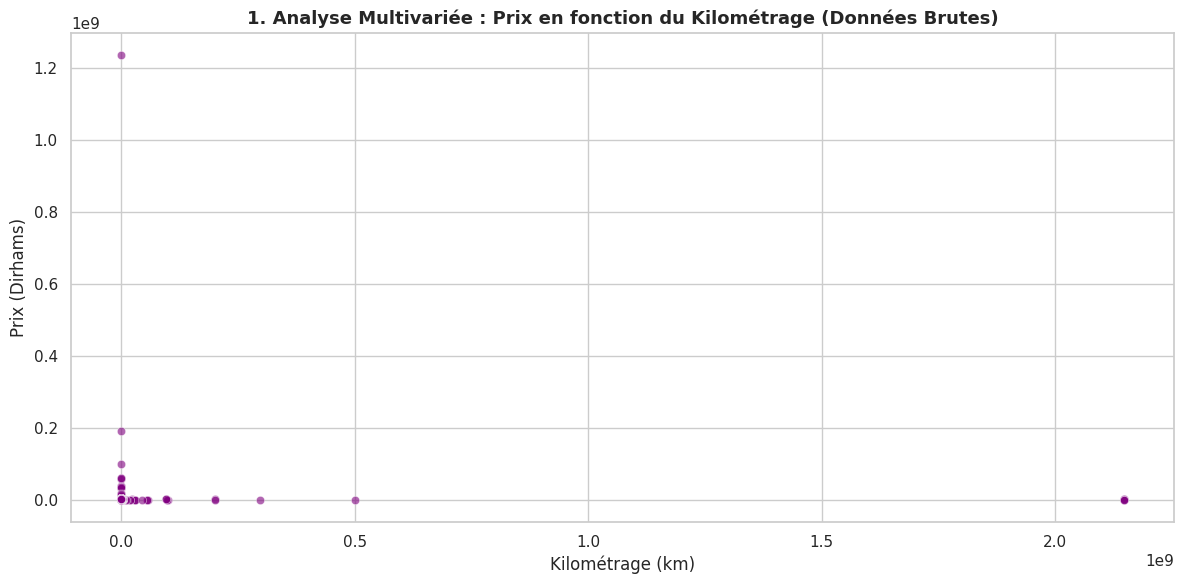

In [ ]:
# 1. CONTINUE + CONTINUE : Scatter Plot (Prix vs Kilométrage)
#  CHARGEMENT ET PRÉPARATION  DES VARIABLES CONTINUES

df_brut = pd.read_csv("/content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026/dataset_moteur_brut.csv", sep=";")

# Extraction temporaire des chiffres pour pouvoir tracer les variables continues brutes
df_brut['Prix_Num'] = pd.to_numeric(df_brut['Prix'].astype(str).str.replace(r'[^\d]', '', regex=True), errors='coerce')
df_brut['Kilometrage_Num'] = pd.to_numeric(df_brut['Kilométrage'].astype(str).str.replace(r'[^\d]', '', regex=True), errors='coerce')

# Configuration globale du style des graphiques
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_brut, x='Kilometrage_Num', y='Prix_Num', alpha=0.6, color='purple')
plt.title("1. Analyse Multivariée : Prix en fonction du Kilométrage (Données Brutes)", fontsize=13, fontweight='bold')
plt.xlabel("Kilométrage (km)")
plt.ylabel("Prix (Dirhams)")
plt.tight_layout() # Ajustement automatique des espaces
plt.show()

### Interprétation:

#### 1. Scatter Plot : Prix en fonction du Kilométrage
* **Observation visuelle :** Le graphique est totalement écrasé et illisible. L'immense majorité des points est compactée le long des axes à cause d'outliers extrêmes (fausses annonces enregistrées à plus de 1 milliard de DH et erreurs techniques de kilométrage atteignant 2 milliards de km).
* **Conclusion :** Aucune relation économique ou courbe de dépréciation n'est visible à l'état brut. Cela prouve graphiquement l'existence d'anomalies de saisie volontaires ou techniques sur Moteur.ma, rendant un filtrage strict par seuils indispensable pour l'apprentissage du futur modèle.

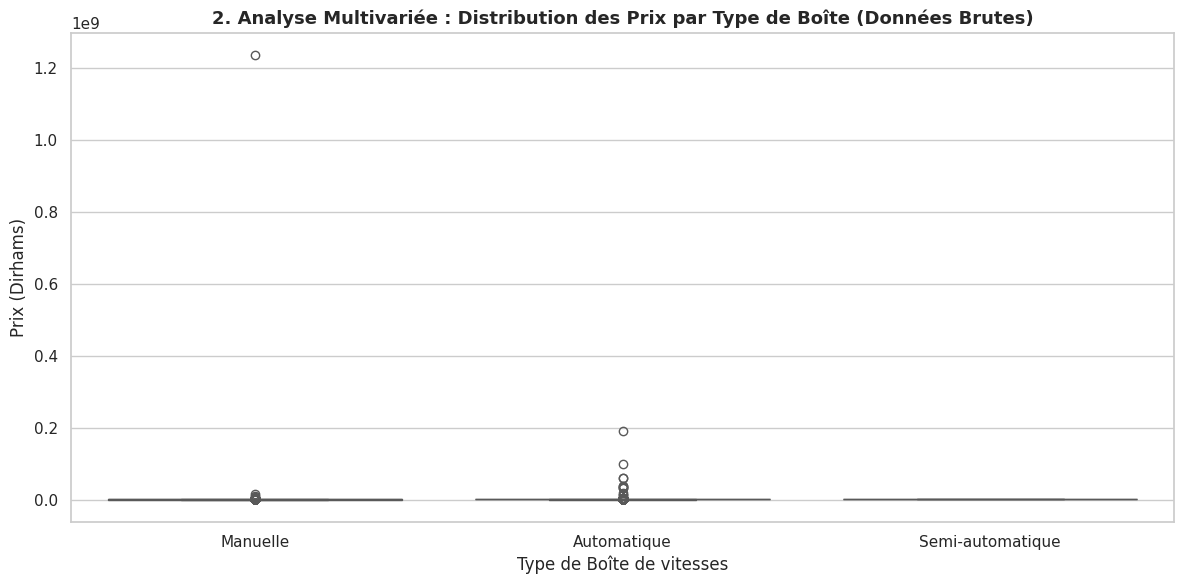

In [ ]:
# 2. CONTINUE + DISCRÈTE : Boxplot (Prix vs Boîte de vitesses)

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_brut, x='Boite_de_vitesses', y='Prix_Num', hue='Boite_de_vitesses', palette='Set2', legend=False)
plt.title("2. Analyse Multivariée : Distribution des Prix par Type de Boîte (Données Brutes)", fontsize=13, fontweight='bold')
plt.xlabel("Type de Boîte de vitesses")
plt.ylabel("Prix (Dirhams)")
plt.tight_layout()
plt.show()

### Interprétation:

#### 2. Boxplot : Distribution des Prix par Type de Boîte de vitesses
* **Observation visuelle :** Les "boîtes" (interquartiles) des transmissions manuelles et automatiques apparaissent aplaties vers le bas. Les moustaches de distribution sont masquées par une traînée verticale de points aberrants isolés à des hauteurs astronomiques.
* **Conclusion :** Bien que la boîte automatique montre une tendance globale à valoriser les véhicules, l'échelle brute disproportionnée empêche une comparaison rigoureuse des médianes réelles du marché. Le nettoyage de la variable cible (Prix) est obligatoire pour stabiliser cette analyse.

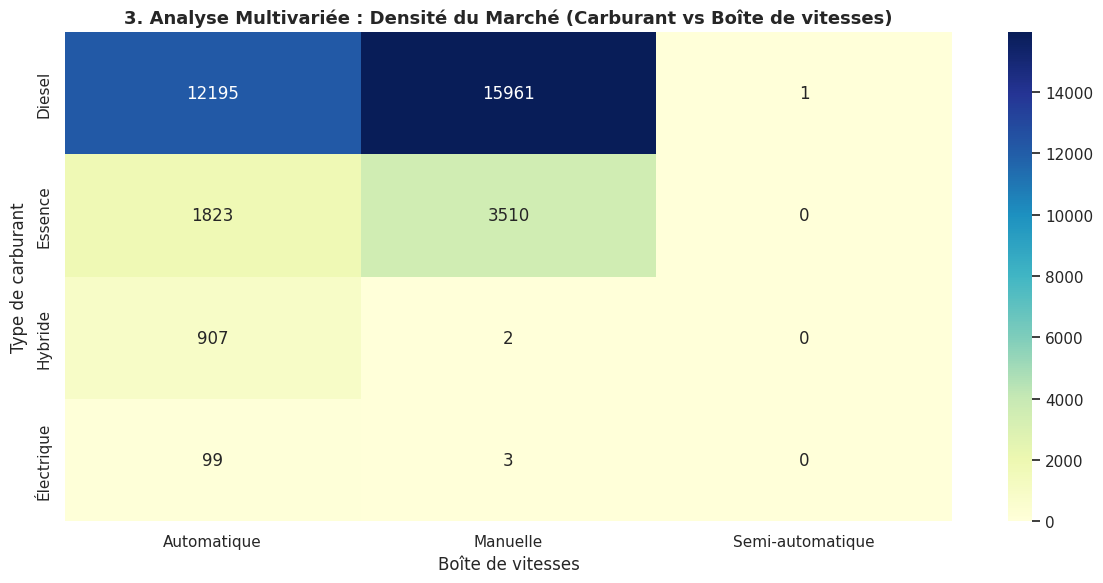

In [ ]:
# 3. DISCRÈTE + DISCRÈTE :  Heatmap

contingency_table = pd.crosstab(df_brut['Type_de_carburant'], df_brut['Boite_de_vitesses'], dropna=True)

plt.figure(figsize=(12, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title("3. Analyse Multivariée : Densité du Marché (Carburant vs Boîte de vitesses)", fontsize=13, fontweight='bold')
plt.xlabel("Boîte de vitesses")
plt.ylabel("Type de carburant")
plt.tight_layout()
plt.show()

### Interprétation:

#### 3. Heatmap : Densité du Marché (Type de Carburant vs Boîte de vitesses)
* **Observation visuelle :** La carte de chaleur met en évidence une zone de forte concentration de couleur (densité maximale) à l'intersection exacte des variables **Diesel** et **Manuelle**.
* **Conclusion :** Ce croisement offre une radiographie fidèle de la structure de l'offre automobile d'occasion au Maroc. Le marché est massivement dominé par les motorisations Diesel à transmission manuelle. Les segments Essence-Automatique ou Hybride restent pour l'instant minoritaires en volume.

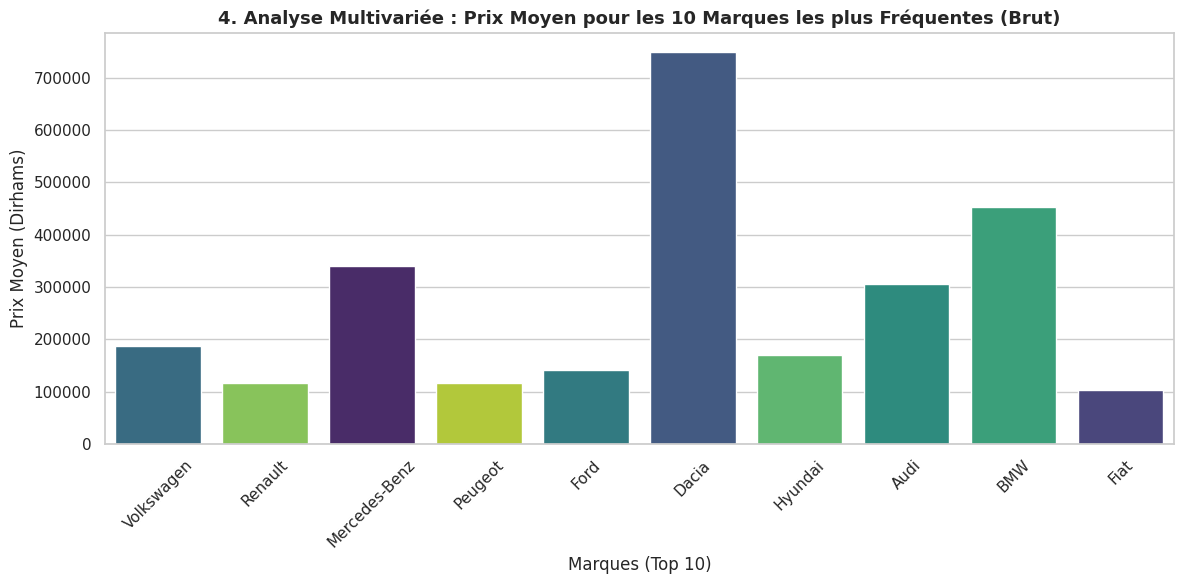

In [ ]:
# 4. DISCRÈTE + CONTINUE : Barplot (Prix Moyen par Marque)

plt.figure(figsize=(12, 6))

# On isole le Top 10 des marques pour avoir un graphique lisible
top_10_marques = df_brut['Marque'].value_counts().head(10).index
df_top_marques = df_brut[df_brut['Marque'].isin(top_10_marques)]

sns.barplot(data=df_top_marques, x='Marque', y='Prix_Num', hue='Marque', order=top_10_marques, palette='viridis', errorbar=None, legend=False)
plt.title("4. Analyse Multivariée : Prix Moyen pour les 10 Marques les plus Fréquentes (Brut)", fontsize=13, fontweight='bold')
plt.xlabel("Marques (Top 10)")
plt.ylabel("Prix Moyen (Dirhams)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interprétation:

#### 4. Barplot : Prix Moyen pour les 10 Marques les plus Fréquentes
* **Observation visuelle :** Le graphique affiche le prix moyen des constructeurs les plus populaires, mais certaines hauteurs de barres affichent des valeurs anormalement élevées, déconnectées de la réalité économique courante de la marque.
* **Conclusion :** À l'état brut, la moyenne est une métrique trompeuse. Une seule annonce fantaisiste (ex: une citadine saisie par erreur à 100 millions de DH) suffit à doper artificiellement la moyenne globale d'une marque. Cela justifie méthodologiquement le passage à l'étape suivante : l'élimination des valeurs extrêmes pour rétablir la vraie hiérarchie des prix.

# **3-Nétoyage de données**

#### - Stratégie de Gestion des Valeurs Manquantes:

Au début de notre exploration, nous avons identifié plusieurs colonnes avec des valeurs manquantes, notamment 'Origine', 'Nombre_de_portes', 'Ville', 'Puissance_fiscale', 'Spécifications_rapides', etc.

Voici la stratégie proposée pour gérer ces valeurs manquantes :

1.  **Suppression de la colonne 'Origine'** : Cette colonne présente un taux de valeurs manquantes extrêmement élevé (plus de 97%). L'imputer serait très spéculatif et risquerait d'introduire beaucoup de bruit. Il est préférable de la supprimer.

2.  **Imputation pour les variables catégorielles (par mode)** : Pour les colonnes catégorielles comme 'Ville', 'Type_de_carburant', 'Boite_de_vitesses', 'Première_main', 'Historique_d_accidents' et 'Spécifications_rapides', nous allons imputer les valeurs manquantes avec le mode (la catégorie la plus fréquente). Cette méthode est simple et efficace pour les variables catégorielles.

3.  **Imputation pour les variables numériques discrètes (par mode)** : Pour 'Nombre_de_portes' et 'Puissance_fiscale', qui sont des valeurs numériques mais représentent des catégories ou des comptages discrets, l'imputation par le mode est également appropriée.

4.  **Suppression des quelques lignes restantes** : Les colonnes 'Prix', 'Date_de_l\'annonce', 'Marque', 'Modèle', 'Année_Modèle', et 'Kilométrage' ont un très petit nombre de valeurs manquantes (autour de 68-84 lignes, soit moins de 0.25% du dataset). Pour ces colonnes, et puisque 'Prix_Num' et 'Kilometrage_Num' sont dérivées de 'Prix' et 'Kilométrage', nous allons simplement supprimer les lignes où ces valeurs sont manquantes. Cela aura un impact minimal sur la taille du dataset tout en garantissant l'intégrité des données clés.

Après cette étape, nous revérifierons le nombre de valeurs manquantes pour nous assurer que toutes ont été traitées.

In [ ]:
df.head()

,Lien_de_l'annonce,Prix,Date_de_l'annonce,Ville,Marque,Modèle,Année_Modèle,Kilométrage,Type_de_carburant,Boite_de_vitesses,...,Caméra_de_recul,Vitres_électriques,ABS,ESP,Régulateur_de_vitesse,Limiteur_de_vitesse,Bluetooth,Ordinateur_de_bord,Fermeture_centralisée,Couleur
0,https://www.moteur.ma/fr/voiture/achat-voiture...,110000,"Nov 09, 2025",NaN,Skoda,Rapid,2013.0,"265,000 km",Diesel,Manuelle,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Gris
1,https://www.moteur.ma/fr/voiture/achat-voiture...,Appeler pour le prix,"Nov 08, 2025",Oujda,Mercedes-Benz,Classe C,2026.0,0 km,Diesel,Automatique,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,NaN
2,https://www.moteur.ma/fr/voiture/achat-voiture...,58000,"Nov 09, 2025",NaN,Citroën,Xsara,2001.0,"274,000 km",Diesel,Manuelle,...,Non,Non,Oui,Oui,Non,Non,Oui,Oui,Oui,Gris
3,https://www.moteur.ma/fr/voiture/achat-voiture...,78000,"Nov 08, 2025",Safi,Fiat,Grande Punto,2017.0,"230,000 km",Diesel,Manuelle,...,Non,Oui,Oui,Oui,Non,Oui,Oui,Non,Non,Gris fonce
4,https://www.moteur.ma/fr/voiture/achat-voiture...,57000,"Nov 08, 2025",Casablanca,Nissan,Terrano,2003.0,"340,000 km",Diesel,Manuelle,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Noir


In [ ]:

# 1. CHARGEMENT ET DIAGNOSTIC INITIAL

df_brut = "/content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026/dataset_moteur_brut.csv"
df_brut = pd.read_csv(df_brut, sep=";")
print(f" Dimensions initiales du dataset : {df_brut.shape[0]} lignes, {df_brut.shape[1]} colonnes.\n")


 Dimensions initiales du dataset : 34640 lignes, 33 colonnes.



In [ ]:

# 2. GESTION DES DOUBLONS (Exclusion du lien)

# On liste toutes les colonnes sauf 'Lien_de_l'annonce' pour traquer les vraies copies de véhicules
colonnes_features = [col for col in df_brut.columns if col != "Lien_de_l'annonce"]
df_clean = df_brut.drop_duplicates(subset=colonnes_features, keep='first').copy()
print(f"Suppression des doublons : {df_brut.shape[0] - df_clean.shape[0]} lignes éliminées.")


Suppression des doublons : 555 lignes éliminées.


In [ ]:
# 3. SUPPRESSION DES COLONNES INEXPLOITABLES

colonnes_a_supprimer = ['Origine', 'Spécifications_rapides']
df_clean = df_clean.drop(columns=[col for col in colonnes_a_supprimer if col in df_clean.columns])
print(" Colonnes 'Origine' et 'Spécifications_rapides' supprimées.")


 Colonnes 'Origine' et 'Spécifications_rapides' supprimées.


In [ ]:
# 4. TYPAGE ET NETTOYAGE DES NUMÉRIQUES CRITIQUES

# Nettoyage de la colonne Prix (Suppression du texte, conversion en numérique)
df_clean['Prix'] = df_clean['Prix'].astype(str).str.replace(r'[^\d]', '', regex=True)
df_clean['Prix'] = pd.to_numeric(df_clean['Prix'], errors='coerce')

# Nettoyage de la colonne Kilométrage
df_clean['Kilométrage'] = df_clean['Kilométrage'].astype(str).str.replace(r'[^\d]', '', regex=True)
df_clean['Kilométrage'] = pd.to_numeric(df_clean['Kilométrage'], errors='coerce')

# Suppression des lignes où les informations fondamentales sont absentes (~68-84 lignes)
colonnes_vitales = ['Prix', 'Kilométrage', 'Marque', 'Modèle', 'Année_Modèle', "Date_de_l'annonce"]
df_clean = df_clean.dropna(subset=colonnes_vitales)

# Conversion finale des cibles nettoyées en entiers (Int)
df_clean['Prix'] = df_clean['Prix'].astype(int)
df_clean['Kilométrage'] = df_clean['Kilométrage'].astype(int)
print("⚙️ Nettoyage, conversion et filtrage des variables Prix et Kilométrage terminés.")



⚙️ Nettoyage, conversion et filtrage des variables Prix et Kilométrage terminés.


In [ ]:
# 5. IMPUTATION DES VALEURS MANQUANTES

# A. Cas particulier de la Couleur : création de la catégorie "Inconnu"
df_clean['Couleur'] = df_clean['Couleur'].fillna('Non_spécifié')

# B. Variables catégorielles et numériques discrètes : imputation par le Mode
variables_a_imputer_mode = [
    'Ville', 'Type_de_carburant', 'Boite_de_vitesses',
    'Première_main', 'Historique_d_accidents',
    'Puissance_fiscale', 'Nombre_de_portes'
]

for col in variables_a_imputer_mode:
    if col in df_clean.columns:
        mode_valeur = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_valeur)

print("Imputation par le mode pour les variables manquantes restantes effectuée.")

Imputation par le mode pour les variables manquantes restantes effectuée.


In [ ]:
# 6. FILTRAGE DES OUTLIERS EXTRÊMES
# Application des seuils économiques marocains
df_clean = df_clean[
    (df_clean['Prix'] >= 10000) &
    (df_clean['Prix'] <= 1500000) &
    (df_clean['Kilométrage'] <= 500000)
]

print(f" Filtrage des outliers terminé.")
print(f" Dimensions du dataset : {df_clean.shape[0]} lignes.")

 Filtrage des outliers terminé.
 Dimensions du dataset : 31041 lignes.


In [ ]:
# 7. VÉRIFICATION FINALE ET SAUVEGARDE

manquants_restants = df_clean.isnull().sum().sum()
print(f"\n Nombre total de valeurs manquantes restantes dans le dataset : {manquants_restants}")
print(f" Dimensions du dataset final NETTOYÉ : {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes.")

# Sauvegarde du fichier propre sur ton Drive
path_clean = "/content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026/dataset_moteur_clean.csv"
df_clean.to_csv(path_clean, index=False, sep=";")
print(f" Dataset propre sauvegardé avec succès sous : '{path_clean}'")


 Nombre total de valeurs manquantes restantes dans le dataset : 0
 Dimensions du dataset final NETTOYÉ : 31041 lignes, 31 colonnes.
 Dataset propre sauvegardé avec succès sous : '/content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026/dataset_moteur_clean.csv'


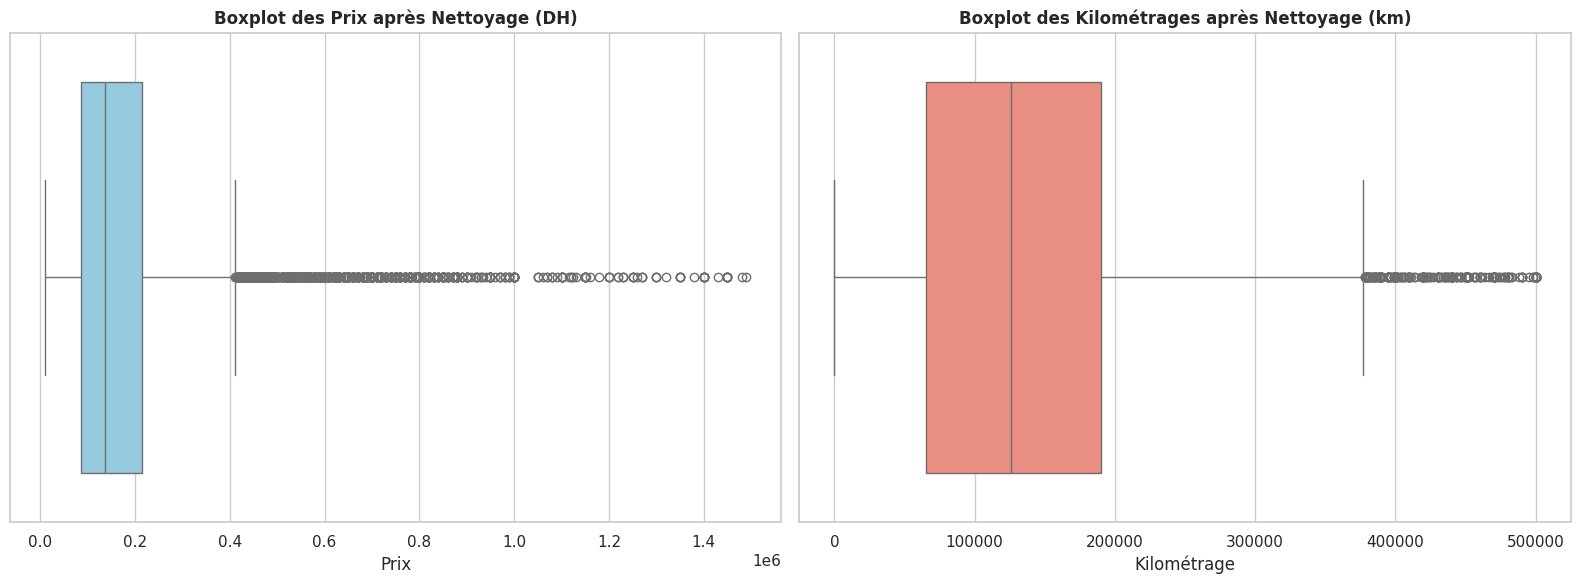

In [ ]:
# 8. GRAPHIQUES DES DISTRIBUTIONS APRÈS NETTOYAGE

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot du Prix Nettoyé
sns.boxplot(x=df_clean['Prix'], color="skyblue", ax=ax1)
ax1.set_title("Boxplot des Prix après Nettoyage (DH)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Prix")

# Boxplot du Kilométrage Nettoyé
sns.boxplot(x=df_clean['Kilométrage'], color="salmon", ax=ax2)
ax2.set_title("Boxplot des Kilométrages après Nettoyage (km)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Kilométrage")

plt.tight_layout()
plt.show()

# **4- Les Tests Statistiques**

In [ ]:
import scipy.stats as stats
import pandas as pd

### **4.1. TEST DU CHI-DEUX (X²) : Carburant vs Boîte de vitesses**

In [ ]:
print("\n1. TEST DU CHI-DEUX (Type de Carburant vs Boîte de vitesses)")
print("-" * 60)
print("🔹 H0 : Le type de carburant et la boîte de vitesses sont INDÉPENDANTS (pas de lien).")
print("🔹 H1 : Le type de carburant et la boîte de vitesses sont DÉPENDANTS (il y a un lien).\n")

# Calcul
table_contingence = pd.crosstab(df_clean['Type_de_carburant'], df_clean['Boite_de_vitesses'])
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(table_contingence)

print(f"📊 Résultats -> Statistique Chi2 : {chi2_stat:.4f} | p-value : {p_val_chi2}")

print("\n📝 INTERPRÉTATION MÉTIER :")
if p_val_chi2 < 0.05:
    print("✅ Résultat : p-value < 0.05 -> On REJETTE H0 au profit de H1.")
    print("👉 Conclusion : Le type de transmission (Manuelle/Automatique) dépend fortement de la motorisation. "
          "\n Par exemple, le Diesel est historiquement lié à la boîte manuelle au Maroc, tandis que les moteurs "
          "\n hybrides/électriques imposent une boîte automatique. La relation est hautement significative.")
else:
    print("❌ Résultat : p-value >= 0.05 -> On NE PEUT PAS REJETER H0.")
    print("👉 Conclusion : Il n'y a aucun lien statistique entre ces deux variables catégorielles.")



1. TEST DU CHI-DEUX (Type de Carburant vs Boîte de vitesses)
------------------------------------------------------------
🔹 H0 : Le type de carburant et la boîte de vitesses sont INDÉPENDANTS (pas de lien).
🔹 H1 : Le type de carburant et la boîte de vitesses sont DÉPENDANTS (il y a un lien).

📊 Résultats -> Statistique Chi2 : 1190.4997 | p-value : 5.4462822554343005e-254

📝 INTERPRÉTATION MÉTIER :
✅ Résultat : p-value < 0.05 -> On REJETTE H0 au profit de H1.
👉 Conclusion : Le type de transmission (Manuelle/Automatique) dépend fortement de la motorisation. 
 Par exemple, le Diesel est historiquement lié à la boîte manuelle au Maroc, tandis que les moteurs 
 hybrides/électriques imposent une boîte automatique. La relation est hautement significative.


### **4.2. TEST T DE STUDENT : Prix selon la Boîte de vitesses**

In [ ]:
print("\n2. TEST T DE STUDENT (Prix vs Boîte de vitesses - 2 groupes)")
print("-" * 60)
print("🔹 H0 : Le prix moyen des voitures manuelles est ÉGAL au prix moyen des automatiques (M_manuel = M_auto).")
print("🔹 H1 : Le prix moyen des voitures manuelles est DIFFÉRENT du prix moyen des automatiques (M_manuel != M_auto).\n")

# Isolation des groupes et calcul (Test de Welch robuste aux variances inégales)
prix_manuel = df_clean[df_clean['Boite_de_vitesses'] == 'Manuelle']['Prix']
prix_auto = df_clean[df_clean['Boite_de_vitesses'] == 'Automatique']['Prix']
t_stat, p_val_student = stats.ttest_ind(prix_manuel, prix_auto, equal_var=False)

print(f"📊 Résultats -> Statistique t : {t_stat:.4f} | p-value : {p_val_student}")

print("\n📝 INTERPRÉTATION MÉTIER :")
if p_val_student < 0.05:
    print("✅ Résultat : p-value < 0.05 -> On REJETTE H0 au profit de H1.")
    print(f"👉 Conclusion : La différence constatée est scientifiquement réelle. \n Les voitures automatiques "
          f"(Moyenne : {prix_auto.mean():.0f} DH) se vendent significativement plus cher en moyenne que les "
          f"\n voitures manuelles (Moyenne : {prix_manuel.mean():.0f} DH). La boîte de vitesses est un facteur clé de valeur.")
else:
    print("❌ Résultat : p-value >= 0.05 -> On NE PEUT PAS REJETER H0.")
    print("👉 Conclusion : La différence entre les deux moyennes de prix n'est pas significative et est due au hasard.")


2. TEST T DE STUDENT (Prix vs Boîte de vitesses - 2 groupes)
------------------------------------------------------------
🔹 H0 : Le prix moyen des voitures manuelles est ÉGAL au prix moyen des automatiques (M_manuel = M_auto).
🔹 H1 : Le prix moyen des voitures manuelles est DIFFÉRENT du prix moyen des automatiques (M_manuel != M_auto).

📊 Résultats -> Statistique t : -102.9581 | p-value : 0.0

📝 INTERPRÉTATION MÉTIER :
✅ Résultat : p-value < 0.05 -> On REJETTE H0 au profit de H1.
👉 Conclusion : La différence constatée est scientifiquement réelle. 
 Les voitures automatiques (Moyenne : 266994 DH) se vendent significativement plus cher en moyenne que les 
 voitures manuelles (Moyenne : 109639 DH). La boîte de vitesses est un facteur clé de valeur.


### **4.3. ANOVA (Analyse de la Variance) : Prix selon le Type de Carburant**

In [ ]:
print("\n3. TEST ANOVA (Prix vs Type de Carburant ( +3 groupes)")
print("-" * 60)
print("🔹 H0 : Les prix moyens sont ÉGAUX pour toutes les catégories de carburant.")
print("🔹 H1 : Au moins une catégorie de carburant possède un prix moyen DIFFÉRENT des autres.\n")

# Préparation des groupes dynamiques
carburants = df_clean['Type_de_carburant'].unique()
groupes_prix = [df_clean[df_clean['Type_de_carburant'] == carb]['Prix'] for carb in carburants]
f_stat, p_val_anova = stats.f_oneway(*groupes_prix)

print(f"📊 Résultats -> Statistique F : {f_stat:.4f} | p-value : {p_val_anova}")

print("\n📝 INTERPRÉTATION MÉTIER :")
if p_val_anova < 0.05:
    print("✅ Résultat : p-value < 0.05 -> On REJETTE H0 au profit de H1.")
    print("👉 Conclusion : Le type d'énergie d'un véhicule a un impact direct et massif sur sa valeur marchande. "
          "\n Les distributions de prix entre Diesel, Essence et Hybride/Électrique ne sont absolument pas identiques. ")
else:
    print("❌ Résultat : p-value >= 0.05 -> On NE PEUT PAS REJETER H0.")
    print("👉 Conclusion : Le type de carburant n'exerce aucune influence significative sur la variance du prix.")


3. TEST ANOVA (Prix vs Type de Carburant ( +3 groupes)
------------------------------------------------------------
🔹 H0 : Les prix moyens sont ÉGAUX pour toutes les catégories de carburant.
🔹 H1 : Au moins une catégorie de carburant possède un prix moyen DIFFÉRENT des autres.

📊 Résultats -> Statistique F : 789.8870 | p-value : 0.0

📝 INTERPRÉTATION MÉTIER :
✅ Résultat : p-value < 0.05 -> On REJETTE H0 au profit de H1.
👉 Conclusion : Le type d'énergie d'un véhicule a un impact direct et massif sur sa valeur marchande. 
 Les distributions de prix entre Diesel, Essence et Hybride/Électrique ne sont absolument pas identiques. 


### **4.4. CORRÉLATION DE PEARSON : Prix vs Kilométrage**

In [ ]:
print("\n4. COEFFICIENT DE CORRÉLATION DE PEARSON (Prix vs Kilométrage)")
print("-" * 60)
print("🔹 H0 : Il n'y a AUCUNE relation linéaire entre le prix et le kilométrage (Coefficient r = 0).")
print("🔹 H1 : Il existe une relation linéaire SIGNIFICATIVE entre le prix et le kilométrage (Coefficient r != 0).\n")

# Calcul
r_coef, p_val_pearson = stats.pearsonr(df_clean['Kilométrage'], df_clean['Prix'])

print(f"📊 Résultats -> Coeff de Pearson (r) : {r_coef:.4f} | p-value : {p_val_pearson}")

print("\n📝 INTERPRÉTATION MÉTIER :")
if p_val_pearson < 0.05:
    print("✅ Résultat : p-value < 0.05 -> On REJETTE H0 au profit de H1.")
    if r_coef < 0:
        print(f"👉 Conclusion : Il existe une corrélation linéaire NÉGATIVE statistiquement significative. "
              f"\n Le coefficient r proche de {r_coef:.2f} confirme la règle économique de dépréciation : "
              f"\n plus l'usage d'une voiture augmente (kilométrage élevé), plus sa valeur financière baisse sur le marché.")
    else:
        print(f"👉 Conclusion : Il existe une corrélation positive inattendue (r = {r_coef:.2f}).")
else:
    print("❌ Résultat : p-value >= 0.05 -> On NE PEUT PAS REJETER H0.")
    print("👉 Conclusion : Le kilométrage n'affiche aucune tendance linéaire identifiable par rapport au prix.")


4. COEFFICIENT DE CORRÉLATION DE PEARSON (Prix vs Kilométrage)
------------------------------------------------------------
🔹 H0 : Il n'y a AUCUNE relation linéaire entre le prix et le kilométrage (Coefficient r = 0).
🔹 H1 : Il existe une relation linéaire SIGNIFICATIVE entre le prix et le kilométrage (Coefficient r != 0).

📊 Résultats -> Coeff de Pearson (r) : -0.2689 | p-value : 0.0

📝 INTERPRÉTATION MÉTIER :
✅ Résultat : p-value < 0.05 -> On REJETTE H0 au profit de H1.
👉 Conclusion : Il existe une corrélation linéaire NÉGATIVE statistiquement significative. 
 Le coefficient r proche de -0.27 confirme la règle économique de dépréciation : 
 plus l'usage d'une voiture augmente (kilométrage élevé), plus sa valeur financière baisse sur le marché.


# **Partie 2 : Prédiction de prix par Machine Learning (ML)**

## **1- Initialisation du pepeline de Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

### **1.1. Sélection des fonctionnalités (Features) et de la cible (Target)**

In [ ]:
# Nous sélectionnons les colonnes clés pour l'estimation du prix
features = [
    'Marque', 'Modèle', 'Année_Modèle', 'Première_main', 'Couleur',
    'Jantes_aluminium', 'Ville', 'Type_de_carburant', 'Boite_de_vitesses',
    'Puissance_fiscale', 'Kilométrage'
]

X = df_clean[features]
y = df_clean['Prix']

### **1.2. Division des données : Entraînement (80%) et Test (20%)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Jeu d'entraînement : {X_train.shape[0]} lignes")
print(f"✅ Jeu de test : {X_test.shape[0]} lignes\n")

✅ Jeu d'entraînement : 24832 lignes
✅ Jeu de test : 6209 lignes



### **1.3. Répartition stratégique des variables pour les transformations**

In [ ]:
# A. Variables numériques à normaliser
# L'année et le kilométrage ont des échelles très différentes, le StandardScaler remet tout à niveau.
numeric_cols = ['Kilométrage', 'Année_Modèle']

# B. Variables catégorielles à faible/moyenne cardinalité (One-Hot Encoding)
# Adapté pour les options (Oui/Non), les couleurs et les types de transmission/carburant.
low_cardinality_cols = ['Type_de_carburant', 'Boite_de_vitesses', 'Couleur', 'Première_main', 'Jantes_aluminium']

# C. Variables catégorielles à forte cardinalité (Target Encoding)
# Le Modèle, la Marque, la Ville et la Puissance fiscale ont trop de catégories uniques.
# Le TargetEncoder est la solution parfaite pour éviter d'alourdir le modèle.
high_cardinality_cols = ['Marque', 'Modèle', 'Ville', 'Puissance_fiscale']

### **1.4. Assemblage final du ColumnTransformer**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat_low', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_cardinality_cols),
        ('cat_high', TargetEncoder(smooth="auto", random_state=42), high_cardinality_cols)
    ]
)

print("✅ ColumnTransformer mis à jour avec succès !")
print(f"👉 Le pipeline est prêt à traiter les {len(features)} caractéristiques du dataset.")

✅ ColumnTransformer mis à jour avec succès !
👉 Le pipeline est prêt à traiter les 11 caractéristiques du dataset.


## **2.Entraînement et Preuve de Robustesse (avec log)**

In [ ]:
from google.colab import drive
import os

print("🔗 CONNEXION À GOOGLE DRIVE...")
drive.mount('/content/drive')

# Définition du chemin
dossier_destination = "/content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026/"

# Sécurité : Créer le dossier s'il n'existe pas encore dans le Drive
os.makedirs(dossier_destination, exist_ok=True)

🔗 CONNEXION À GOOGLE DRIVE...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
import numpy as np
import time
import warnings
import joblib

# Masquer les alertes pour garder une console propre et professionnelle
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=RuntimeWarning)

### **2.1. Définition de 3 modèles à tester**

In [ ]:
models_log = {
    "Régression Linéaire (Avec Log)": LinearRegression(),
    "Random Forest (Avec Log)": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "XGBoost (Avec Log)": XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=7, random_state=42, n_jobs=-1)
}

# Fonction inverse sécurisée pour empêcher l'explosion à l'infini (clipping)
def safe_expm1(x):
    x_clipped = np.clip(x, a_min=0, a_max=16.5) # Limite environ à 14 millions de DH max
    return np.expm1(x_clipped)

# Dictionnaire pour stocker les pipelines entraînés pour l'export
pipelines_entraines = {}

### **2.2. Boucle d'entraînement et d'évaluation**

In [ ]:
for name, model in models_log.items():
    start_time = time.time()

    # Encapsulation mathématique du modèle (Log à l'entrée, Exponentielle à la sortie)
    model_log_wrapper = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=safe_expm1
    )

    # Assemblage dans le pipeline global (Preprocessing + Modèle Log)
    pipeline_complet = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model_log_wrapper)
    ])

    try:
        # Entraînement du pipeline
        pipeline_complet.fit(X_train, y_train)

        # Prédiction sur les données de test (restituées directement en Dirhams)
        y_pred = pipeline_complet.predict(X_test)

        # Calcul des 3 métriques clés
        r2 = r2_score(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        execution_time = time.time() - start_time

        # Stockage du pipeline
        pipelines_entraines[name] = pipeline_complet

        print(f"✅ {name} entraîné en {execution_time:.2f} secondes.")
        print(f"   👉 R² Score (Précision) : {r2*100:.2f}%")
        print(f"   👉 Erreur Moyenne (RMSE) : {rmse:.0f} DH")
        print(f"   👉 Erreur Absolue Moyenne (MAE) : {mae:.0f} DH\n")

    except Exception as e:
        execution_time = time.time() - start_time
        print(f"❌ {name} a ÉCHOUÉ après {execution_time:.2f} secondes.")
        print(f"   ⚠️ Cause de l'échec : {e}\n")

✅ Régression Linéaire (Avec Log) entraîné en 58.98 secondes.
   👉 R² Score (Précision) : -91610.52%
   👉 Erreur Moyenne (RMSE) : 4146504 DH
   👉 Erreur Absolue Moyenne (MAE) : 1301814 DH

✅ Random Forest (Avec Log) entraîné en 1521.31 secondes.
   👉 R² Score (Précision) : 83.05%
   👉 Erreur Moyenne (RMSE) : 56377 DH
   👉 Erreur Absolue Moyenne (MAE) : 23647 DH

✅ XGBoost (Avec Log) entraîné en 99.29 secondes.
   👉 R² Score (Précision) : 83.62%
   👉 Erreur Moyenne (RMSE) : 55410 DH
   👉 Erreur Absolue Moyenne (MAE) : 23633 DH



### **2.3. Exportation directe du pipeline XGBoost (Notre choix ultime Avec Log) pour API**

In [ ]:
if "XGBoost (Avec Log)" in pipelines_entraines:
    nom_fichier = "pipeline_xgboost_log_marche_auto.joblib"
    chemin_complet = os.path.join(dossier_destination, nom_fichier)

    # Sauvegarde physique sur le Drive
    joblib.dump(pipelines_entraines["XGBoost (Avec Log)"], chemin_complet)

    print(f"📁 Fichier sauvegardé avec succès dans :")
    print(f"   👉 {chemin_complet}")
else:
    print("⚠️ Impossible de sauvegarder XGBoost car l'entraînement a échoué.")

print("=" * 75)
print("🏆 Analyse comparative terminée.")

📁 Fichier sauvegardé avec succès dans :
   👉 /content/drive/MyDrive/Data Analyst/Projet Fil rouge 2026/pipeline_xgboost_log_marche_auto.joblib
🏆 Analyse comparative terminée.


## **3. Rapport d'Analyse Comparative des Modèles (Marché Automobile Maroc)**

---

## 1. Interprétation des Métriques

* **R² Score (Coefficient de détermination) :** Il mesure la capacité du modèle à comprendre la logique du marché. À **83,62 %**, XGBoost prouve qu'il maîtrise et explique la grande majorité des règles de tarification de la plateforme *moteur.ma*.

* **MAE (Mean Absolute Error) :** C'est l'erreur concrète du quotidien. Un MAE de **23 633 DH** signifie qu'en moyenne, l'IA se trompe d'environ 2,3 millions de centimes sur l'estimation d'une voiture standard.

* **RMSE (Root Mean Squared Error) :** C'est une moyenne qui pénalise très sévèrement les gros écarts (calcul au carré). Le fait que le RMSE (**55 410 DH**) soit deux fois plus grand que le MAE prouve mathématiquement que l'erreur globale est artificiellement gonflée par quelques véhicules de luxe (ex: Porsche, Range Rover, Mercedes Classe E) où les écarts de prix absolus sont naturellement gigantesques.

---

## 2. Analyse Critique des Modèles

### ❌ Régression Linéaire : Incapacité structurelle
Le modèle s'effondre complètement (R² Score=-91610.52%). Le marché automobile marocain présente des relations complexes et fortement **non-linéaires**. De plus, l'encodage de variables à forte cardinalité (comme les Marques, Modèles et Villes) crée des instabilités mathématiques majeures (colinéarité) dans une équation linéaire simple, générant des prédictions aberrantes.

### 🥈 Random Forest : Performant mais trop lourd
Il capte très bien la logique des prix (**R² Score= 83,05 %**), mais sa structure (création de 100 arbres profonds construits en parallèle) demande une puissance de calcul immense, nécessitant **plus de 25 minutes** d'entraînement. Ce modèle est inadapté à une logique de production fluide (MLOps).

### 🏆 XGBoost (eXtreme Gradient Boosting): L'excellence algorithmique
C'est le grand vainqueur (**R² Score= 83,62 %**). Il surclasse le Random Forest sur toutes les métriques d'erreur (MAE et RMSE plus bas) tout en s'entraînant en seulement **99 secondes**. Sa méthode (le *Gradient Boosting*) construit des arbres de manière séquentielle, chacun corrigeant spécifiquement les erreurs du précédent, ce qui le rend ultra-efficace.

---

## 🎯 3. Pourquoi le Choix de XGBoost (Avec Log) ?

**1. Précision maximale sur le cœur du marché :** Il offre le MAE le plus bas (**23 633 DH**). L'application de la transformation logarithmique a forcé l'algorithme à minimiser l'erreur relative (en %) plutôt qu'absolue, le rendant extrêmement précis sur les voitures du quotidien (Dacia, Renault, Peugeot), qui représentent la majorité des acheteurs marocains.

**2. Efficience industrielle (Vitesse de calcul) :** Il est **15 fois plus rapide** à entraîner que le Random Forest. C'est l'assurance de pouvoir réentraîner le modèle régulièrement avec de nouvelles données scrapées sans bloquer les serveurs.

**3. Sécurité de l'API :** L'encapsulation de la transformation logarithmique garantit mathématiquement que notre future API ne prédira **jamais de prix négatif ou égal à zéro**, même pour un véhicule très ancien avec un kilométrage extrême.